In [1]:
#load feature selected dataset and other necessary libraries
import pandas as pd

df = pd.read_csv('selected_features_network_dataset.csv')
X_res = df.drop('label', axis=1)
y = df['label']

In [2]:
# Display selected features
print("Selected Features:")
print(X_res.columns.tolist())
print("\nNumber of Selected Features:", X_res.shape[1])


Selected Features:
['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'ssl_version', 'ssl_cipher', 'http_uri', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'proto_icmp', 'proto_tcp', 'proto_udp', 'service_dce_rpc', 'service_dns', 'service_ftp', 'service_gssapi', 'service_http', 'service_n/a', 'service_smb', 'service_ssl', 'conn_state_OTH', 'conn_state_REJ', 'conn_state_RSTO', 'conn_state_RSTR', 'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2', 'conn_state_S3', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR', 'dns_AA_F', 'dns_AA_T', 'dns_AA_n/a', 'dns_RD_F', 'dns_RD_T', 'dns_RD_n/a', 'dns_RA_F', 'dns_RA_T', 'dns_RA_n/a', 'dns_rejected_F', 'dns_rejected_T', 'dns_rejected_n/a', 'ssl_resumed_F', 'ssl_resumed_T', 'ssl_established_F', 'ssl_established_

In [3]:
#split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y, test_size=0.25, random_state=42, stratify=y)

In [4]:
# optimize hyperparameters for xgboost classifier
import xgboost as xgb
import optuna

def objective_xgb(trial):
    param = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth',5, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.5, 2.0),
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_leaves': trial.suggest_int('max_leaves', 1, 9),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'device': 'cuda',
        'tree_method': 'hist',
        'random_state': 42,
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)

    return accuracy

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-27 15:08:17,599] A new study created in memory with name: no-name-423d9d7a-9f3a-42a8-8e65-3de5d2ebbd8a
C:\Users\Francis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:774: UserWarning: [15:08:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the

In [5]:
#show best hyperparameters found for xgboost
print("Best hyperparameters: ", study_xgb.best_params)
print("Best accuracy: ", study_xgb.best_value)
#train final model with best hyperparameters
best_params_xgb = study_xgb.best_params
xgb_final_model = xgb.XGBClassifier(**best_params_xgb)
xgb_final_model.fit(X_train, y_train)
final_accuracy = xgb_final_model.score(X_test, y_test)
print("Final model accuracy: ", final_accuracy)


Best hyperparameters:  {'learning_rate': 0.24436481863463644, 'max_depth': 10, 'subsample': 0.9582240745337832, 'min_child_weight': 0.6171569646322967, 'n_estimators': 287, 'max_leaves': 9}
Best accuracy:  0.9979250037053505
Final model accuracy:  0.9978441596938706


Accuracy:  0.9978441596938706
Precision:  0.9979783276726508
Recall:  0.9977093888110381
F1 Score:  0.997843840120745
Confusion Matrix:
 [[37034    75]
 [   85 37023]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     37109
           1       1.00      1.00      1.00     37108

    accuracy                           1.00     74217
   macro avg       1.00      1.00      1.00     74217
weighted avg       1.00      1.00      1.00     74217



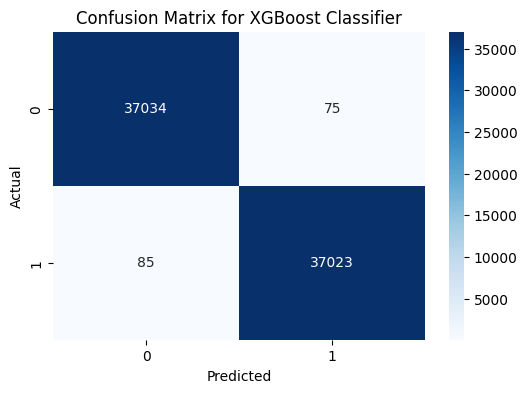

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_xgb = xgb_final_model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_xgb))
print("Precision: ", precision_score(y_test, y_pred_xgb))
print("Recall: ", recall_score(y_test, y_pred_xgb))
print("F1 Score: ", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
import matplotlib.pyplot as plt
import seaborn as sns
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()


In [7]:
#hyperparameter optimization for decision tree classifier
from sklearn.tree import DecisionTreeClassifier

def objective_dt(trial):
    param = {
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy','log_loss']),
        'splitter': trial.suggest_categorical('splitter', ['best', 'random']),
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'random_state': 42,
    }
    model = DecisionTreeClassifier(**param)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    return accuracy

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=100)

[I 2026-01-27 15:10:40,274] A new study created in memory with name: no-name-578261b4-a215-4810-83b9-b3633aa39296
[I 2026-01-27 15:10:40,390] Trial 0 finished with value: 0.831372866054947 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 7, 'max_features': 'sqrt', 'ccp_alpha': 0.07214864507131982}. Best is trial 0 with value: 0.831372866054947.
[I 2026-01-27 15:10:40,506] Trial 1 finished with value: 0.8310764380128542 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'max_features': 'log2', 'ccp_alpha': 0.08893988522662975}. Best is trial 0 with value: 0.831372866054947.
[I 2026-01-27 15:10:40,606] Trial 2 finished with value: 0.8310764380128542 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 6, 'max_features': 'log2', 'ccp_alpha': 0.08376575649224055}. Best is trial 0 with value: 0.831372866054947.
[I 2026-01-27 15:10:40,706] Trial 3 finished with value: 0.8353342226174596 and parameters: {'criterion

In [8]:
#show best hyperparameters found for decision tree
print("Best hyperparameters: ", study_dt.best_params)
print("Best accuracy: ", study_dt.best_value)
#train final model with best hyperparameters
best_params_dt = study_dt.best_params
dt_final_model = DecisionTreeClassifier(**best_params_dt)
dt_final_model.fit(X_train, y_train)
final_accuracy = dt_final_model.score(X_test, y_test)
print("Final model accuracy: ", final_accuracy)

Best hyperparameters:  {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 9, 'max_features': None, 'ccp_alpha': 3.0833469399668936e-05}
Best accuracy:  0.9945565032270235
Final model accuracy:  0.9945430292251102


Accuracy:  0.9945430292251102
Precision:  0.9911940258558389
Recall:  0.9979519241133987
F1 Score:  0.9945614953873424
Confusion Matrix:
 [[36780   329]
 [   76 37032]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     37109
           1       0.99      1.00      0.99     37108

    accuracy                           0.99     74217
   macro avg       0.99      0.99      0.99     74217
weighted avg       0.99      0.99      0.99     74217



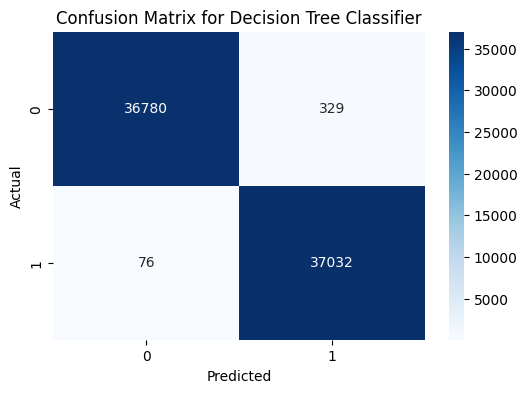

In [9]:
#obtain evaluation metrics for decision tree classifier
y_pred_dt = dt_final_model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_dt))
print("Precision: ", precision_score(y_test, y_pred_dt))
print("Recall: ", recall_score(y_test, y_pred_dt))
print("F1 Score: ", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

In [10]:
#hyperparameter optimization for random forest classifier
from sklearn.ensemble import RandomForestClassifier

def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
    }
    model = RandomForestClassifier(**param)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    return accuracy

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=100)

[I 2026-01-27 15:12:02,119] A new study created in memory with name: no-name-4dcf906c-4c35-4825-b5c4-bc3def201652
[I 2026-01-27 15:12:24,798] Trial 0 finished with value: 0.9451742862147486 and parameters: {'n_estimators': 252, 'max_depth': 7, 'max_features': 'log2', 'criterion': 'log_loss', 'ccp_alpha': 0.042044084036104296, 'bootstrap': True}. Best is trial 0 with value: 0.9451742862147486.
[I 2026-01-27 15:14:51,137] Trial 1 finished with value: 0.9454033442472749 and parameters: {'n_estimators': 115, 'max_depth': 17, 'max_features': None, 'criterion': 'gini', 'ccp_alpha': 0.09846367588644167, 'bootstrap': False}. Best is trial 1 with value: 0.9454033442472749.
[I 2026-01-27 15:15:07,772] Trial 2 finished with value: 0.945147338210922 and parameters: {'n_estimators': 211, 'max_depth': 6, 'max_features': 'log2', 'criterion': 'entropy', 'ccp_alpha': 0.0766207470236855, 'bootstrap': True}. Best is trial 1 with value: 0.9454033442472749.
[I 2026-01-27 15:16:05,805] Trial 3 finished with

In [11]:
#show best hyperparameters found for random forest
print("Best hyperparameters: ", study_rf.best_params)
print("Best accuracy: ", study_rf.best_value)
#train final model with best hyperparameters
best_params_rf = study_rf.best_params
rf_final_model = RandomForestClassifier(**best_params_rf)
rf_final_model.fit(X_train, y_train)
final_accuracy = rf_final_model.score(X_test, y_test)
print("Final model accuracy: ", final_accuracy)

Best hyperparameters:  {'n_estimators': 173, 'max_depth': 13, 'max_features': 'sqrt', 'criterion': 'log_loss', 'ccp_alpha': 8.36597869232153e-05, 'bootstrap': True}
Best accuracy:  0.9952167293207755
Final model accuracy:  0.9951358853092958


Accuracy:  0.9951358853092958
Precision:  0.9931821232049389
Recall:  0.9971165247386008
F1 Score:  0.9951454352298859
Confusion Matrix:
 [[36855   254]
 [  107 37001]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00     37109
           1       0.99      1.00      1.00     37108

    accuracy                           1.00     74217
   macro avg       1.00      1.00      1.00     74217
weighted avg       1.00      1.00      1.00     74217



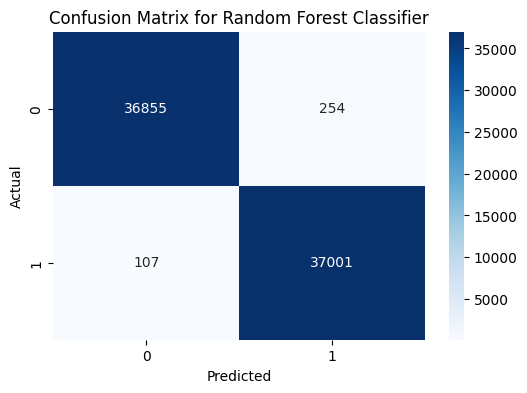

In [12]:
#obtain evaluation metrics for random forest classifier
y_pred_rf = rf_final_model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision: ", precision_score(y_test, y_pred_rf))
print("Recall: ", recall_score(y_test, y_pred_rf))
print("F1 Score: ", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()

In [13]:
#save the three models
import joblib
joblib.dump(xgb_final_model, 'xgb_final_model.pkl')
joblib.dump(dt_final_model, 'dt_final_model.pkl')
joblib.dump(rf_final_model, 'rf_final_model.pkl')

['rf_final_model.pkl']